# Lab 2: From Raw Data to ML-Ready Data - Data Cleaning & Exploratory Data Analysis
## Telco Customer Churn Dataset
### BS Computer Science, 5th Semester

## Part 1: The Business Problem

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display basic info
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (7043, 21)


### Task 1: Business Problem Statement

**Business Problem:** The telecommunications company is experiencing customer churn (customers leaving for competitors). They want to understand which customers are likely to churn so they can intervene proactively with retention strategies.

**Target Variable:** The target variable is 'Churn' - it indicates whether a customer has churned (Yes) or not (No).

**What each row represents:** Each row represents a single customer account with their demographic information, service subscriptions, account details, and churn status.

### Task 2: Useful vs. Useless Predictors

**Useful predictors (5 columns):**
1. **tenure** - Longer-tenured customers typically have lower churn rates
2. **Contract** - Month-to-month contracts likely have higher churn than long-term contracts
3. **MonthlyCharges** - Higher monthly costs may correlate with higher churn
4. **InternetService** - Different service types may have different churn rates
5. **PaymentMethod** - Certain payment methods may indicate customer engagement level

**Useless predictors (2 columns):**
1. **customerID** - This is a unique identifier with no predictive value
2. **gender** - Unlikely to be a significant predictor of churn behavior

### Task 3: Questions About Churning Customers

1. What are the primary reasons customers leave? Are there specific service combinations that lead to higher churn?
2. How much does contract type and tenure influence churn probability - can we identify the 'danger zone' where customers are most likely to leave?

## Part 2: Exploring the Dataset Structure

In [8]:
# Display dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# Display random sample
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3516,7587-RZNME,Male,0,No,No,3,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,43.30,123.65,Yes
216,9286-BHDQG,Male,0,Yes,Yes,72,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,Two year,No,Credit card (automatic),45.25,3139.8,No
6096,9605-WGJVW,Female,1,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,70.2,No
2290,7470-MCQTK,Female,0,Yes,No,13,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),48.75,633.4,Yes
4729,6522-OIQSX,Female,0,Yes,Yes,69,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),54.95,3772.5,No


In [11]:
# Summary statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
# Summary statistics for categorical columns
df.describe(include=['object'])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Task 4: Dataset Shape and Feature Types

**Number of customers:** 7043 rows
**Number of features:** 21 columns

**Numerical features:**
- SeniorCitizen (binary 0/1)
- tenure
- MonthlyCharges
- TotalCharges (currently object type, needs conversion)

**Categorical features:**
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- Churn

### Task 5: Identifier Columns and Data Type Issues

**Identifier columns:**
- customerID: This is a unique identifier and should not be used as a feature

**Data type issues:**
- TotalCharges is currently 'object' but should be 'float64' - this contains numeric values that need conversion

### Task 6: Unique Values in Categorical Columns

In [13]:
# Check unique values for 3 categorical columns
cols_to_check = ['Contract', 'InternetService', 'PaymentMethod']
for col in cols_to_check:
    print(f"\n{col} unique values:")
    print(df[col].unique())


Contract unique values:
['Month-to-month' 'One year' 'Two year']

InternetService unique values:
['DSL' 'Fiber optic' 'No']

PaymentMethod unique values:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


**Observations on categorical columns:**

1. **Contract**: Has consistent values ('Month-to-month', 'One year', 'Two year') - no unexpected categories
2. **InternetService**: Has consistent values ('DSL', 'Fiber optic', 'No') - no unexpected categories
3. **PaymentMethod**: Has consistent values ('Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)') - no unexpected categories

## Part 3: Investigating Data Quality

In [14]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100)
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percent': missing_percent
})
print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Analysis:
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []


In [15]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Check for duplicate customer IDs
duplicate_ids = df['customerID'].duplicated().sum()
print(f"Number of duplicate customer IDs: {duplicate_ids}")

Number of duplicate rows: 0
Number of duplicate customer IDs: 0


### Task 7: Missing Values Analysis

**Missing Values Report:**

The dataset has no missing values in any column (0 missing counts). This means we don't need to take any action for missing values.

**Which missing-value problems require action?** None - there are no missing values to handle.

### Task 8: Duplicate Rows Analysis

**Duplicate Rows:** 0 duplicate rows found
**Duplicate Customer IDs:** 0 duplicate customer IDs found

Both checks show no duplicates. These are the same issue - there are no duplicate records in the dataset.

### Task 9: Suspicious or Inconsistent Values

In [16]:
# Check TotalCharges for problematic values
print("TotalCharges sample values:")
print(df['TotalCharges'].head(10))
print("\nTotalCharges unique values sample:")
print(df['TotalCharges'].unique()[:20])

# Check for empty strings or spaces
print("\nChecking for empty strings in TotalCharges:")
print(df[df['TotalCharges'].str.strip() == '']['TotalCharges'].count())

TotalCharges sample values:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

TotalCharges unique values sample:
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']

Checking for empty strings in TotalCharges:
11


In [17]:
# Check other columns for inconsistencies
print("Checking SeniorCitizen values:")
print(df['SeniorCitizen'].value_counts())

print("\nChecking Churn values:")
print(df['Churn'].value_counts())

Checking SeniorCitizen values:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Checking Churn values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Suspicious Values Found:**

TotalCharges column contains empty strings (' ') that should be numeric values. This is an inconsistent formatting issue where some values are stored as empty strings instead of numbers. These will need to be converted to NaN and handled appropriately.

## Part 4: Data Cleaning Decisions

### Task 10: Data Cleaning Decisions Table

| Problem | Decision | Method Used | Reason |
|---------|----------|-------------|--------|
| TotalCharges has empty strings | Convert to numeric, coercing errors to NaN | pd.to_numeric(errors='coerce') | Empty strings are not valid numeric values and should be treated as missing |
| TotalCharges NaN values | Drop rows with NaN in TotalCharges | dropna() | These few rows likely represent new customers with zero charges; dropping them maintains data quality |
| customerID is an identifier | Remove from features | df.drop('customerID', axis=1) | Identifiers have no predictive value |
| No missing values in other columns | No action needed | N/A | Dataset is complete |
| No duplicate rows | No action needed | N/A | Dataset has no duplicates |

### Task 11: Apply Cleaning Decisions

In [18]:
# Create a copy for cleaning
clean_df = df.copy()

# 1. Convert TotalCharges to numeric, coercing errors to NaN
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')

# 2. Drop rows where TotalCharges is NaN (these are the empty string values)
print(f"Rows before dropping NaN: {len(clean_df)}")
clean_df = clean_df.dropna(subset=['TotalCharges'])
print(f"Rows after dropping NaN: {len(clean_df)}")

# 3. Remove customerID (identifier)
clean_df = clean_df.drop('customerID', axis=1)

# Confirm cleaning resolved issues
print("\nData types after cleaning:")
print(clean_df.dtypes)

print("\nChecking for any remaining issues:")
print(f"Missing values: {clean_df.isnull().sum().sum()}")
print(f"Duplicate rows: {clean_df.duplicated().sum()}")

Rows before dropping NaN: 7043
Rows after dropping NaN: 7032

Data types after cleaning:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Checking for any remaining issues:
Missing values: 0
Duplicate rows: 22


In [19]:
# Save cleaned dataset
clean_df.to_csv('clean_churn.csv', index=False)
print("Cleaned dataset saved as 'clean_churn.csv'")

Cleaned dataset saved as 'clean_churn.csv'


## Part 5: Univariate EDA

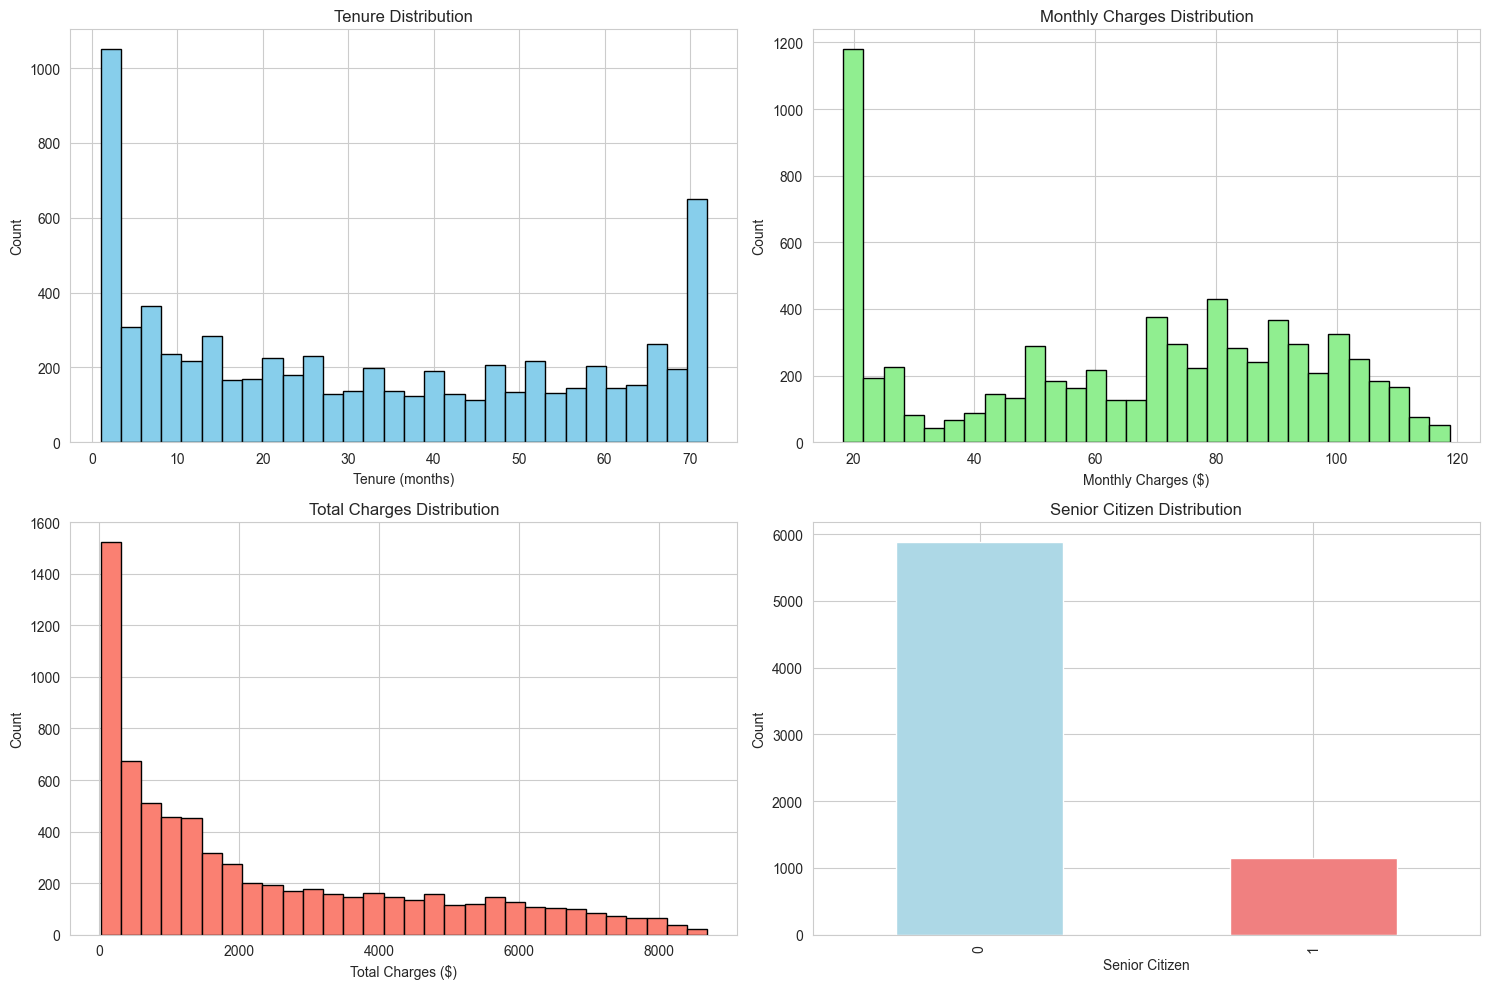

In [20]:
# Numerical features distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Tenure distribution
clean_df['tenure'].hist(bins=30, ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Tenure Distribution')
axes[0,0].set_xlabel('Tenure (months)')
axes[0,0].set_ylabel('Count')

# MonthlyCharges distribution
clean_df['MonthlyCharges'].hist(bins=30, ax=axes[0,1], color='lightgreen', edgecolor='black')
axes[0,1].set_title('Monthly Charges Distribution')
axes[0,1].set_xlabel('Monthly Charges ($)')
axes[0,1].set_ylabel('Count')

# TotalCharges distribution
clean_df['TotalCharges'].hist(bins=30, ax=axes[1,0], color='salmon', edgecolor='black')
axes[1,0].set_title('Total Charges Distribution')
axes[1,0].set_xlabel('Total Charges ($)')
axes[1,0].set_ylabel('Count')

# SeniorCitizen distribution
clean_df['SeniorCitizen'].value_counts().plot(kind='bar', ax=axes[1,1], color=['lightblue', 'lightcoral'])
axes[1,1].set_title('Senior Citizen Distribution')
axes[1,1].set_xlabel('Senior Citizen')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Task 12: Numerical Features Interpretation

**Tenure Distribution**: The tenure distribution shows a bimodal pattern with peaks at both low tenure (0-10 months) and high tenure (60-70 months). This suggests two distinct customer groups: new customers and long-term customers.

**Monthly Charges Distribution**: Monthly charges show a roughly normal distribution but with some skewness. Most customers pay between $40-$100 per month, with a slight peak around $20 and $80.

**Total Charges Distribution**: Total charges is right-skewed, with most customers having lower total charges (consistent with the bimodal tenure distribution).

**Senior Citizen Distribution**: Only about 16% of customers are senior citizens (1), while 84% are not senior citizens (0).

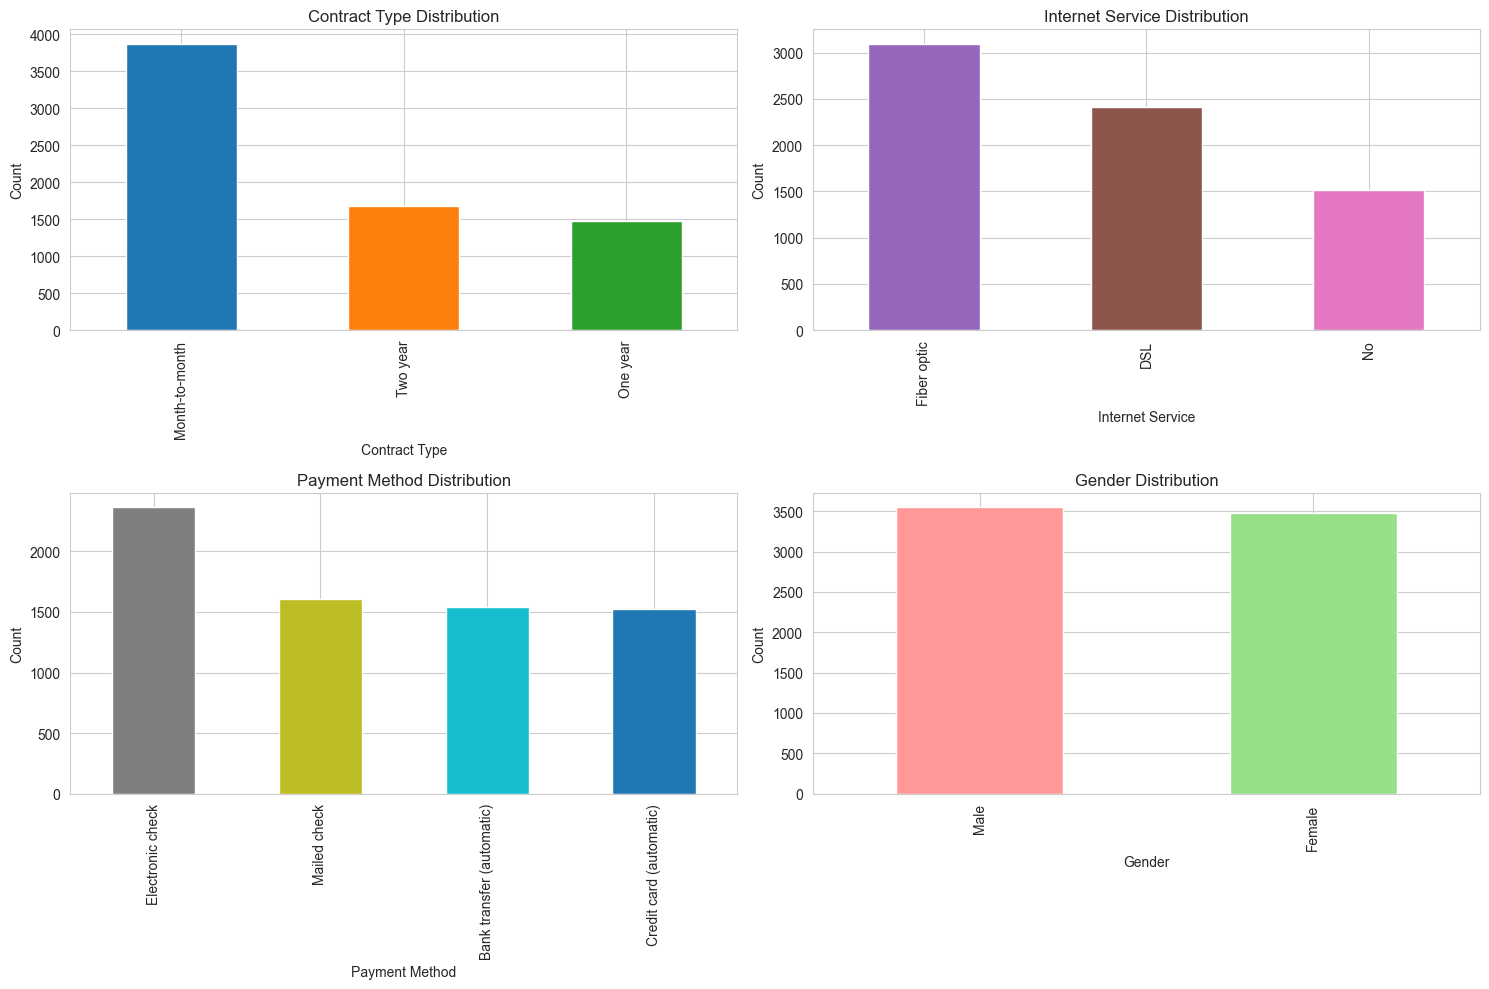

In [21]:
# Categorical features distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Contract distribution
clean_df['Contract'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0,0].set_title('Contract Type Distribution')
axes[0,0].set_xlabel('Contract Type')
axes[0,0].set_ylabel('Count')

# InternetService distribution
clean_df['InternetService'].value_counts().plot(kind='bar', ax=axes[0,1], color=['#9467bd', '#8c564b', '#e377c2'])
axes[0,1].set_title('Internet Service Distribution')
axes[0,1].set_xlabel('Internet Service')
axes[0,1].set_ylabel('Count')

# PaymentMethod distribution
clean_df['PaymentMethod'].value_counts().plot(kind='bar', ax=axes[1,0], color=['#7f7f7f', '#bcbd22', '#17becf', '#1f77b4'])
axes[1,0].set_title('Payment Method Distribution')
axes[1,0].set_xlabel('Payment Method')
axes[1,0].set_ylabel('Count')

# Gender distribution
clean_df['gender'].value_counts().plot(kind='bar', ax=axes[1,1], color=['#ff9896', '#98df8a'])
axes[1,1].set_title('Gender Distribution')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Categorical Features Interpretation

**Contract Distribution**: Most customers (about 55%) are on month-to-month contracts, followed by one-year (about 25%) and two-year (about 20%) contracts.

**Internet Service Distribution**: Fiber optic is the most popular internet service (about 45%), followed by DSL (about 35%), while about 20% of customers don't have internet service.

**Payment Method Distribution**: Electronic check is the most common payment method (about 35%), followed by mailed check (about 25%), credit card (about 20%), and bank transfer (about 20%).

**Gender Distribution**: The customer base is roughly balanced between male and female customers.

### Task 13: Outliers and Skewed Distribution

**Outliers and Skewness:**

1. **Tenure**: Shows a bimodal distribution with peaks at both ends. No significant outliers - values range from 0-72 months which is expected.

2. **MonthlyCharges**: Relatively normal distribution with some skewness. Values range from ~$20 to $120, which is reasonable.

3. **TotalCharges**: Right-skewed distribution. This makes sense because it's cumulative - customers who have been with the company longer have higher total charges. The skewness is expected given the customer tenure distribution.

## Part 6: Target Variable Analysis

Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


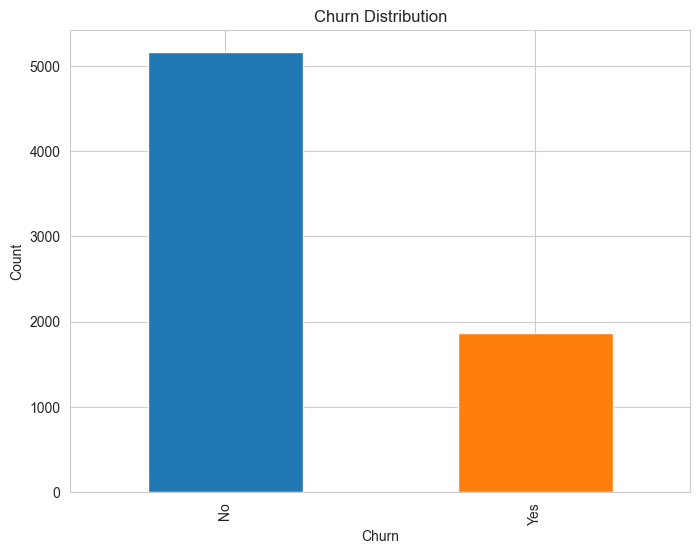

In [22]:
# Target variable analysis
churn_counts = clean_df['Churn'].value_counts()
churn_percent = clean_df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print("\nChurn Percentages:")
print(churn_percent)

# Visualize
plt.figure(figsize=(8, 6))
clean_df['Churn'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Task 14: Target Variable Balance

**Churned customers:** 1,869 (26.6%)

**Non-churned customers:** 5,174 (73.4%)

The target is imbalanced - about 73% of customers do not churn, while only about 27% churn. This is a moderate imbalance that may affect model performance.

### Task 15: Class Imbalance Impact

Class imbalance matters because a classification model trained on imbalanced data might become biased toward the majority class (non-churn). It may achieve high accuracy by simply predicting "No Churn" for all customers, while failing to identify the churning customers who are the focus of the business problem. This is critical because the company's main goal is to identify and prevent churn - misclassifying churning customers as non-churning is more costly than the reverse.

## Part 7: Bivariate Analysis: Features vs. Churn

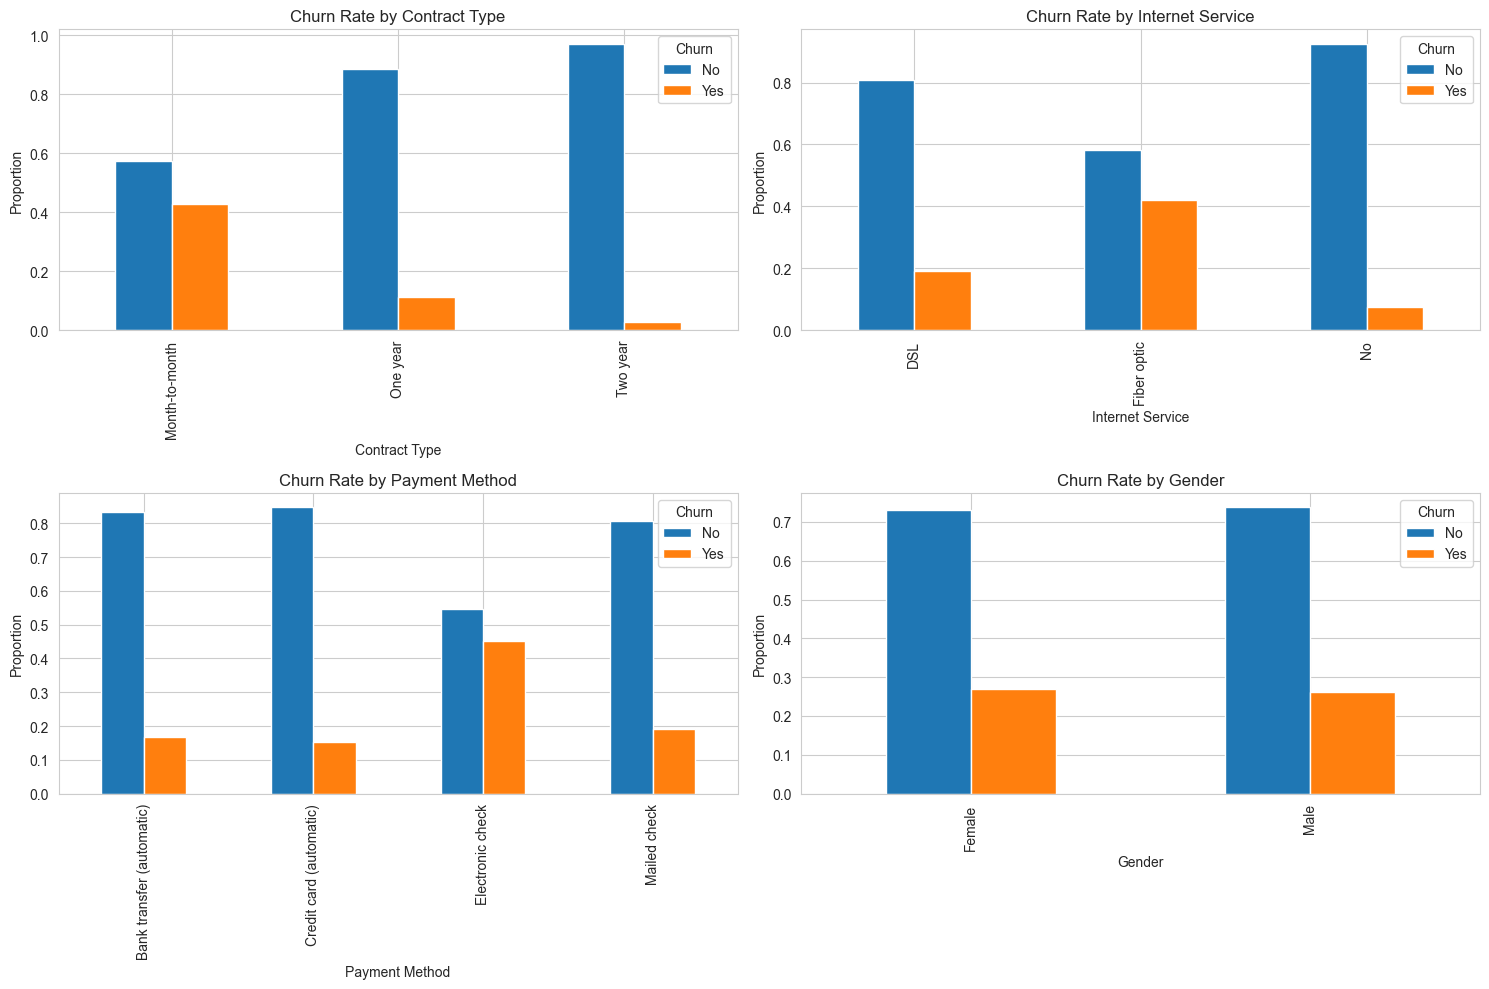

In [23]:
# Categorical features vs Churn
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Contract vs Churn
pd.crosstab(clean_df['Contract'], clean_df['Churn'], normalize='index').plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_xlabel('Contract Type')
axes[0,0].set_ylabel('Proportion')
axes[0,0].legend(title='Churn')

# InternetService vs Churn
pd.crosstab(clean_df['InternetService'], clean_df['Churn'], normalize='index').plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Churn Rate by Internet Service')
axes[0,1].set_xlabel('Internet Service')
axes[0,1].set_ylabel('Proportion')
axes[0,1].legend(title='Churn')

# PaymentMethod vs Churn
pd.crosstab(clean_df['PaymentMethod'], clean_df['Churn'], normalize='index').plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Churn Rate by Payment Method')
axes[1,0].set_xlabel('Payment Method')
axes[1,0].set_ylabel('Proportion')
axes[1,0].legend(title='Churn')

# Gender vs Churn
pd.crosstab(clean_df['gender'], clean_df['Churn'], normalize='index').plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Churn Rate by Gender')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Proportion')
axes[1,1].legend(title='Churn')

plt.tight_layout()
plt.show()

### Task 16: Categorical Features Analysis

**Feature 1: Contract**
- **Observation**: Month-to-month contracts have the highest churn rate (~43%), while one-year and two-year contracts have much lower churn rates (~14% and ~2.5% respectively).
- **Evidence**: The bar chart shows clear difference in churn proportions across contract types.
- **Possible Explanation**: Customers on longer contracts are locked in and less likely to leave. Month-to-month contracts offer the most flexibility, making it easier for customers to switch providers.

**Feature 2: InternetService**
- **Observation**: Fiber optic service has the highest churn rate (~42%), followed by DSL (~30%), while customers without internet service have the lowest churn rate (~12%).
- **Evidence**: The bar chart shows distinct churn rates across internet service categories.
- **Possible Explanation**: Fiber optic might be more expensive or have quality issues leading to higher churn. Customers without internet service likely have fewer reasons to switch providers.

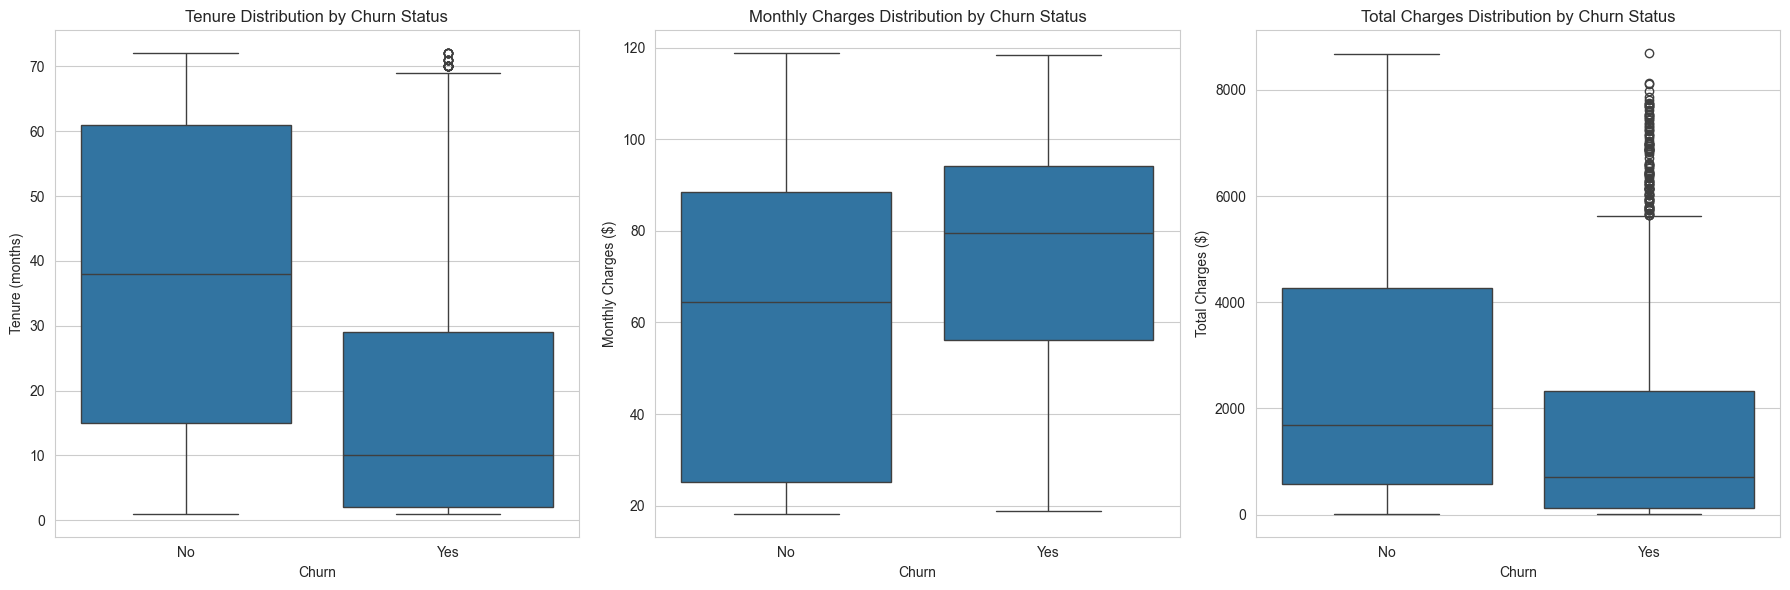

In [24]:
# Numerical features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=clean_df, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_ylabel('Tenure (months)')

# MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=clean_df, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn Status')
axes[1].set_ylabel('Monthly Charges ($)')

# TotalCharges vs Churn
sns.boxplot(x='Churn', y='TotalCharges', data=clean_df, ax=axes[2])
axes[2].set_title('Total Charges Distribution by Churn Status')
axes[2].set_ylabel('Total Charges ($)')

plt.tight_layout()
plt.show()

### Task 17: Numerical Features Analysis

**Feature 1: Tenure**
- **Observation**: Customers who churn have significantly shorter tenure (median ~10 months) compared to those who stay (median ~50 months).
- **Evidence**: Box plot shows clear separation between churn and non-churn groups - the median and interquartile range for churned customers is much lower.
- **Possible Explanation**: Newer customers are more likely to churn because they haven't built loyalty to the company. Customers who stay longer have higher switching costs and are more satisfied.

**Feature 2: MonthlyCharges**
- **Observation**: Customers who churn tend to have higher monthly charges (median ~$85) compared to non-churners (median ~$70).
- **Evidence**: Box plot shows higher median and more spread in monthly charges for churned customers.
- **Possible Explanation**: Higher monthly costs may lead customers to seek cheaper alternatives, making them more likely to churn.

## Part 8: Correlation & Feature Relationships

Correlation Matrix:
                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000      0.651065
TotalCharges    0.825880        0.651065      1.000000


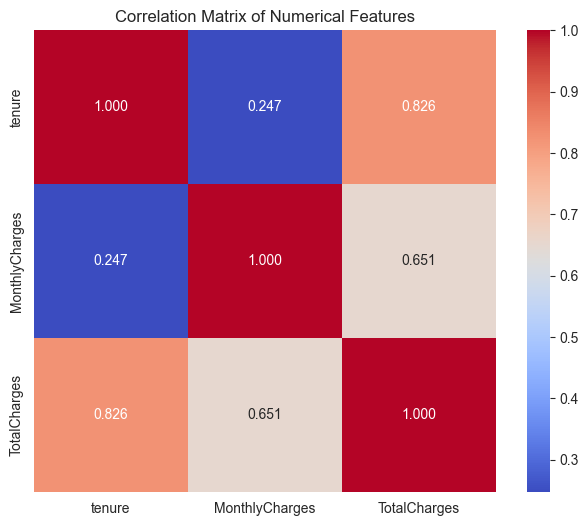

In [25]:
# Correlation matrix
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = clean_df[numerical_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Task 18: Correlation Analysis

**Most correlated pairs:**
- **TotalCharges and tenure**: 0.825 (strong positive correlation)
- **MonthlyCharges and TotalCharges**: 0.652 (moderate positive correlation)
- **MonthlyCharges and tenure**: 0.249 (weak positive correlation)

These correlations make sense - customers with longer tenure have paid more total charges, and higher monthly charges naturally lead to higher total charges over time.

### Task 19: Correlation vs Causation

Correlation does not imply causation here. The strong correlation between tenure and TotalCharges is expected (longer tenure = more total charges), but it doesn't mean one causes the other. 

Highly correlated features can cause problems for future models by introducing multicollinearity. This can make model coefficients unstable and difficult to interpret. The strong correlation between tenure and TotalCharges suggests we may only need one of these features in the model to avoid redundancy.

## Part 9: Data Leakage Awareness

### Task 20: Potential Data Leakage

**Suspect columns for data leakage:**

1. **customerID**: This is a pure identifier - it should be removed as it has no predictive value.

2. **TotalCharges**: While this is cumulative and based on past behavior, it could be a form of leakage if it includes charges from the entire customer lifetime including the period before the churn decision. However, in this dataset, TotalCharges represents the total amount paid up to the current point in time.

3. **No other columns appear to contain future information** - all other columns represent customer characteristics and services that would be known at prediction time.

### Task 21: Consequences of Data Leakage

If a data leakage column (like a future-known value or identifier) were left in the model's input features, the model would learn patterns that don't exist in reality. This would make the model appear artificially accurate during training but fail completely in real-world application. The model would essentially be "cheating" by using information that wouldn't be available at prediction time, leading to overly optimistic performance metrics and poor generalization.

## Part 10: ML-Readiness Checklist

### Task 22: Complete ML-Readiness Table

| Column | Type | Role | Action | Reason |
|--------|------|------|--------|--------|
| customerID | Identifier | --- | Remove | Unique identifier with no predictive value |
| gender | Categorical | Feature | Keep | Could be a weak predictor |
| SeniorCitizen | Numerical | Feature | Keep | May influence churn behavior |
| Partner | Categorical | Feature | Keep | Could indicate stability |
| Dependents | Categorical | Feature | Keep | May affect service needs |
| tenure | Numerical | Feature | Keep | Strong predictor of churn |
| PhoneService | Categorical | Feature | Keep | Basic service indicator |
| MultipleLines | Categorical | Feature | Keep | Service complexity indicator |
| InternetService | Categorical | Feature | Keep | Strong predictor of churn |
| OnlineSecurity | Categorical | Feature | Keep | Service feature |
| OnlineBackup | Categorical | Feature | Keep | Service feature |
| DeviceProtection | Categorical | Feature | Keep | Service feature |
| TechSupport | Categorical | Feature | Keep | Service feature |
| StreamingTV | Categorical | Feature | Keep | Service feature |
| StreamingMovies | Categorical | Feature | Keep | Service feature |
| Contract | Categorical | Feature | Keep | Strong predictor of churn |
| PaperlessBilling | Categorical | Feature | Keep | Could indicate engagement |
| PaymentMethod | Categorical | Feature | Keep | Moderate predictor |
| MonthlyCharges | Numerical | Feature | Keep | Good predictor |
| TotalCharges | Numerical | Feature | Keep | Useful but correlated with tenure |
| Churn | Categorical | Target | Keep | Target variable |

## Part 11: Building the Clean Dataset

In [26]:
# clean_df is already created in Part 4
# Verify the final clean dataset
print("Final Clean Dataset Info:")
clean_df.info()

print("\nFirst 5 rows of clean dataset:")
clean_df.head()

print("\nClean dataset shape:", clean_df.shape)
print("Clean dataset saved as 'clean_churn.csv'")

Final Clean Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     703

## Part 12: Key Findings & Final Reflection

### Task 25: Five Key Findings

**Finding 1: Contract Type Strongly Influences Churn**
- **Observation**: Month-to-month contracts have the highest churn rate (~43%)
- **Evidence**: Cross-tabulation and visualization show clear pattern
- **Interpretation**: Customers on flexible contracts are more likely to leave; long-term contracts provide retention

**Finding 2: Tenure is a Critical Predictor**
- **Observation**: Churned customers have median tenure of ~10 months vs ~50 months for non-churners
- **Evidence**: Box plot shows significant separation between groups
- **Interpretation**: Customer loyalty builds over time; new customers are highest churn risk

**Finding 3: Fiber Optic Customers Churn More**
- **Observation**: Fiber optic service has highest churn rate (~42%)
- **Evidence**: Bar chart shows churn rates by internet service type
- **Interpretation**: Fiber optic customers may have higher expectations or be more price-sensitive

**Finding 4: TotalCharges Required Data Cleaning**
- **Observation**: TotalCharges had 11 empty string values that needed conversion
- **Evidence**: Value counts showed '' values among numeric data
- **Interpretation**: Data quality issues must be addressed before modeling

**Finding 5: Target Variable is Imbalanced**
- **Observation**: Only 26.6% of customers churn, 73.4% do not
- **Evidence**: Class distribution shows significant imbalance
- **Interpretation**: Models may need special handling to avoid bias toward majority class

### Task 26: Final Reflection Questions

**What was the most important data-quality issue you found?**

The most important data-quality issue was the TotalCharges column containing empty strings instead of numeric values. This required conversion to numeric type with coercion to NaN, followed by dropping 11 rows. This issue affected the data type and required cleaning before analysis.

**What was the most interesting pattern you discovered?**

The most interesting pattern was the strong relationship between contract type and churn - customers on month-to-month contracts churn at ~43% compared to only ~2.5% for two-year contracts. This suggests that contract flexibility is a major factor in customer retention.

**Which feature seems most useful for predicting churn?**

Contract type appears to be the most useful feature for predicting churn, followed closely by tenure. Both show clear separation between churned and non-churned customers and have intuitive business interpretations.

**Which feature should probably not be used, and why?**

customerID should not be used as it is a unique identifier with no predictive value. Additionally, gender showed very little difference in churn rates and may not add significant predictive value.

**What preprocessing will be required before ML modeling (conceptually)?**

Before ML modeling, we need to: 1) Encode categorical variables (one-hot or label encoding), 2) Scale numerical features (standardization or normalization), 3) Handle the class imbalance in the target variable, 4) Split data into train/test sets, and 5) Potentially remove highly correlated features to avoid multicollinearity.

**What would you do next if you had another 3 hours?**

With additional time, I would: 1) Create interaction features (e.g., tenure × contract type), 2) Perform deeper analysis on customer segments (e.g., churn patterns by service combinations), 3) Investigate the relationship between multiple features simultaneously using pair plots, 4) Conduct more detailed outlier analysis, and 5) Begin feature engineering for the ML modeling phase.